# 串扰仿真 v13 —— 长焦 A 组 16 激光器编码鬼影检测（理想 δ 回波）

> **目标**：忠实记录"谁发光 → 碰到多远的物体 → 被谁在自己的 TOF 窗里收到 → 算成了多远"，
> 用几个特定距离验证仿真逻辑是否正确。暂不做全距离扫描、不做波形/蒙卡（那是 v44 的事）。
>
> **v13 相对 v12**：
> ① **cell5 只保留 kick 栅格图**（删掉时间轴放大下图），比例改约 4:3 更紧凑；
>    格内文字改为编码 **`tx + delta/12`**（如 `50+3/12`），delta 取 Excel tdelay 原值仅展示；
> ② **cell9 加开关 `PLOT_NEGLIGIBLE`**（默认 False，不画空间可忽略鬼影）；柱内文字改为 **`LxKx`**；
> ③ 删除所有 `plt.savefig`——只在 notebook 内展示，不落地 PNG。
>
> 继承 v12：全图统一配色 `laser_color`（同一激光器恒定同色）；逐回波堆叠柱；
> 全局 `CROSSTALK_MAX_GAP`（激光器编号间隔 > 此值的串扰视为空间可忽略，默认 2）。

## 一、物理模型（理想化）
- 回波是 **δ 函数**，被 **100% 确定性** 记录到准确时刻。
- 物体回波 **被每一个激光器接收**：只要回波时刻落在某激光器的 TOF 窗内，就被它记录。
- 因此天然涌现三类鬼影：
  1. **同 kick 串扰**：同一 kick 内多个激光器几乎同时发光，回波互相落进对方的窗；
  2. **距离混叠（TOF 外鬼影）**：D>300m 的回波超过 2μs 窗，落入后续 kick 的窗；
  3. **编码残差**：接收器按【自己】的编码扣延迟测距，残留 (发射编码−接收编码) 决定鬼影落点。

## 二、时间 / 距离公式
```
t_fire = kick×KICK_SPACING + tx_trig_dly·1ns + delta_dly·(1/12)ns + fpga·8ns
t_ref  = t_fire − delta_dly·(1/12)ns          # "激光器(除去 delta_dly 的延时)"
t_echo = t_fire_发 + 2D/c
记录条件： t_fire_收 ≤ t_echo ≤ t_fire_收 + TOF_WINDOW
rec_tof = t_echo − t_ref_收        rec_dist = rec_tof · c / 2
is_true = (发激光==收激光) 且 (同一 kick)     # 其余均为鬼影
```

## 三、本版参数
- 数据源：`Elephant 时序表.xlsx` 的 **长焦** tab、**A 组**（16 激光器，每个发 4 次光）。
- `KICK_SPACING = 2.2 μs`，`TOF_WINDOW = 2000 ns`（固定），`1ns bin = 15cm`，`2000ns = 300m`。
- 编码：`tx_trig_dly` 用 Excel(0/50ns)；`delta_dly=0`（留接口）；`fpga_jitter=0`（留接口）。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import openpyxl

# 中文字体
for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]; break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

# ---- 物理常数 ----
C_LIGHT = 2.99792458e8      # 光速 [m/s]
NS = 1e-9                   # 1 ns [s]

# ---- 系统时序常数（用户设定，勿擅改）----
KICK_SPACING = 2.2e-6       # 相邻 kick 基线间隔 [s]（2.2 μs）
TOF_WINDOW   = 2000e-9      # 固定 TOF 窗宽 [s]（2000 ns）
D_UNAMBIG    = TOF_WINDOW * C_LIGHT / 2.0   # 最大无模糊距离 [m]（=300m）

# ---- 串扰空间可忽略阈值（v12 新增全局）----
#   认为激光器【编号间隔 > CROSSTALK_MAX_GAP】的两者，空间上离得远，其相互串扰可忽略。
#   例：阈值=2 时，L1 与 L2/L3 不可忽略（gap=1/2），L1 与 L4 可忽略（gap=3）。
#   仅用于【分析/统计/标注】层面把远距离串扰过滤掉；核心 detect_echoes 仍忠实记录全部回波。
CROSSTALK_MAX_GAP = 2       # 可改：编号间隔 ≤ 此值才算"不可忽略的串扰"

print("模块导入完成。")
print(f"  光速          = {C_LIGHT:.6e} m/s")
print(f"  1 ns 往返距离 = {C_LIGHT*NS/2*100:.2f} cm")
print(f"  KICK_SPACING  = {KICK_SPACING*1e6:.2f} μs")
print(f"  TOF_WINDOW    = {TOF_WINDOW*1e9:.0f} ns  ->  最大无模糊距离 D_UNAMBIG = {D_UNAMBIG:.1f} m")
print(f"  kick 窗间隙   = {(KICK_SPACING-TOF_WINDOW)*1e9:.0f} ns  ->  对应距离 {(KICK_SPACING-TOF_WINDOW)*C_LIGHT/2:.1f} m")
print(f"  串扰可忽略阈值 CROSSTALK_MAX_GAP = {CROSSTALK_MAX_GAP}（激光器编号间隔 > 此值则串扰忽略）")


模块导入完成。
  光速          = 2.997925e+08 m/s
  1 ns 往返距离 = 14.99 cm
  KICK_SPACING  = 2.20 μs
  TOF_WINDOW    = 2000 ns  ->  最大无模糊距离 D_UNAMBIG = 299.8 m
  kick 窗间隙   = 200 ns  ->  对应距离 30.0 m
  串扰可忽略阈值 CROSSTALK_MAX_GAP = 2（激光器编号间隔 > 此值则串扰忽略）


In [2]:
# ============================================================================
# 读取时序：长焦 tab、A 组（列 8~23 = kick 0~15）
# ============================================================================
# 表结构（长焦 tab）：
#   R3 = 各 kick 的 TOF(us)   R4 = tdelay(=delta_dly, 1/12ns 步长)   R6 = kick 编号
#   数据行：C2=HDC C3=TX_TRG C5=CHG C6=LASER，列 8~23 = 各 kick 的 tx_trig_dly（空=该 kick 不发光）
EXCEL_FILE = "Elephant 时序表.xlsx"
wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
ws = wb["长焦"]                       # 第一个 tab = 长焦
COL_A = range(8, 24)                   # A 组 16 个 kick 所在列

# ---- A 组每个 kick 的 delta_dly（Excel 第 4 行 tdelay，单位 1/12 ns）----
#   本版 use_delta_dly=False 时不参与计算，但先解析保留，方便以后打开。
tdelay_A = {}
for c in COL_A:
    v = ws.cell(4, c).value
    tdelay_A[c - 8] = int(v) if v is not None else 0

# ---- A 组每个 kick 的 TOF(us)（Excel 第 3 行；本版统一用固定 TOF_WINDOW，这里仅供参考）----
tof_excel_A = {}
for c in COL_A:
    v = ws.cell(3, c).value
    tof_excel_A[c - 8] = float(v) if v is not None else None

# ---- 解析所有激光器发光行 ----
#   每个发光单元： (laser_id, kick_idx, tx_trig_dly)
laser_fires_raw = []      # 原始发光记录（未算时间）
laser_ids = []
for r in range(7, 106):
    las = ws.cell(r, 6).value
    if las is None:
        continue
    try:
        lid = int(las)
    except (ValueError, TypeError):
        continue
    laser_ids.append(lid)
    for k, c in enumerate(COL_A):
        v = ws.cell(r, c).value
        if v is not None:
            laser_fires_raw.append((lid, k, int(v)))    # (激光器, kick, tx_trig_dly)

laser_ids = sorted(set(laser_ids))
N_LASERS = len(laser_ids)

print(f"从 {EXCEL_FILE} [长焦/A组] 读取：{N_LASERS} 个激光器，{len(laser_fires_raw)} 次发光事件")
print(f"\nA 组各 kick 参数：")
print(f"  kick   : " + " ".join(f"{k:>3d}" for k in range(16)))
print(f"  delta  : " + " ".join(f"{tdelay_A[k]:>3d}" for k in range(16)) + "   (1/12 ns, 本版=0)")
print(f"  tof(us): " + " ".join(f"{str(tof_excel_A[k]):>3s}" for k in range(16)) + "   (Excel原值, 本版统一2μs)")

print(f"\n各激光器发光次数：")
for lid in laser_ids:
    fires = [(k, tx) for (l, k, tx) in laser_fires_raw if l == lid]
    ks = ",".join(f"K{k}(tx={tx})" for k, tx in fires)
    print(f"  L{lid:>2d}: {len(fires)}次 -> {ks}")


从 Elephant 时序表.xlsx [长焦/A组] 读取：16 个激光器，64 次发光事件

A 组各 kick 参数：
  kick   :   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15
  delta  :   0   3   6   0   3   6   9   0   3   6   9   0   3   6   9   9   (1/12 ns, 本版=0)
  tof(us): 2.0 2.0 2.0 2.0 2.0 2.0 2.0 1.0 1.0 1.0 2.0 1.0 1.0 1.0 1.0 1.0   (Excel原值, 本版统一2μs)

各激光器发光次数：
  L 1: 4次 -> K7(tx=0),K8(tx=0),K9(tx=0),K15(tx=0)
  L 2: 4次 -> K11(tx=0),K12(tx=0),K13(tx=0),K14(tx=0)
  L 3: 4次 -> K7(tx=50),K8(tx=50),K9(tx=50),K15(tx=50)
  L 4: 4次 -> K11(tx=50),K12(tx=50),K13(tx=50),K14(tx=50)
  L 5: 4次 -> K0(tx=0),K1(tx=0),K2(tx=0),K6(tx=0)
  L 6: 4次 -> K3(tx=0),K4(tx=0),K5(tx=0),K10(tx=0)
  L 7: 4次 -> K0(tx=50),K1(tx=50),K2(tx=50),K6(tx=50)
  L 8: 4次 -> K3(tx=50),K4(tx=50),K5(tx=50),K10(tx=50)
  L 9: 4次 -> K0(tx=0),K1(tx=0),K2(tx=0),K6(tx=0)
  L10: 4次 -> K3(tx=0),K4(tx=0),K5(tx=0),K10(tx=0)
  L11: 4次 -> K0(tx=50),K1(tx=50),K2(tx=50),K6(tx=50)
  L12: 4次 -> K3(tx=50),K4(tx=50),K5(tx=50),K10(tx=50)
  L13: 4次 -> K7(tx=0),K8(tx=0),K9(tx

In [3]:
# ============================================================================
# 编码配置（三参数开关 + 数值接口）与发光时刻计算
# ============================================================================
# ---- v12：全局统一配色 ----
#   v11 用 tab20，它是"深浅成对"设计（0/1深浅蓝、2/3深浅橙…），导致相邻激光器一深一浅。
#   改为 HSV 只变色相、明度/饱和度恒定 —— 同一激光器在所有图里恒定同色，且深浅一致。
import matplotlib.colors as _mcolors
def laser_color(laser_id):
    """激光器 -> 固定颜色（明度/饱和度恒定，只按编号变色相）。全图统一调用此函数。"""
    idx = (laser_id - 1) % max(N_LASERS, 1)
    h = idx / max(N_LASERS, 1)              # 色相均匀铺满
    return _mcolors.hsv_to_rgb((h, 0.65, 0.92))   # 固定饱和度0.65、明度0.92 => 深浅一致

# ---- v12：串扰是否可忽略（按激光器编号间隔）----
def crosstalk_negligible(emit_laser, recv_laser):
    """编号间隔 > CROSSTALK_MAX_GAP 视为空间上离得远、串扰可忽略。返回 True=可忽略。"""
    return abs(emit_laser - recv_laser) > CROSSTALK_MAX_GAP

# 三个编码块（需求第 4 行）：
#   1) tx_trig_dly : 1 ns 步长 —— 本版按 Excel 用 0 / 50 ns
#   2) delta_dly   : 1/12 ns 步长 —— 本版全设 0（探高反目标才用；接口保留）
#   3) fpga_jitter : 8 ns 步长的 FPGA 随机抖动 —— 本版全设 0（重要编码方式；接口保留）
ENC = {
    "use_tx_trig_dly": True,    # True: 用 Excel 的 0/50ns；False: 全当 0
    "use_delta_dly":   False,   # 本版 False（全 0）。改 True 则启用 Excel 第4行 tdelay
    "use_fpga_jitter": False,   # 本版 False（全 0）。改 True 则启用 FPGA_JITTER_STEPS
}

# FPGA 抖动接口：每激光器的抖动步数（×8ns）。本版全 0。
#   注：真实 FPGA 抖动可能逐 shot 随机；此处先做"每激光器一个固定步数"的占位接口。
FPGA_JITTER_STEPS = {lid: 0 for lid in laser_ids}


def delta_offset(kick_idx):
    """该 kick 的 delta_dly 贡献 [s]（1/12 ns 步长）。use_delta_dly=False 时恒为 0。"""
    if not ENC["use_delta_dly"]:
        return 0.0
    return tdelay_A.get(kick_idx, 0) * (NS / 12.0)


def fpga_offset(laser_id):
    """该激光器的 FPGA 抖动贡献 [s]（8 ns 步长）。use_fpga_jitter=False 时恒为 0。"""
    if not ENC["use_fpga_jitter"]:
        return 0.0
    return FPGA_JITTER_STEPS.get(laser_id, 0) * 8.0 * NS


def fire_time(laser_id, kick_idx, tx_trig_dly):
    """激光器实际发光时刻 [s]（绝对时间轴）。
       = kick 基线 + tx_trig_dly·1ns + delta_dly·(1/12)ns + fpga·8ns"""
    base = kick_idx * KICK_SPACING
    t_tx = (tx_trig_dly * NS) if ENC["use_tx_trig_dly"] else 0.0
    return base + t_tx + delta_offset(kick_idx) + fpga_offset(laser_id)


def ref_time(laser_id, kick_idx, tx_trig_dly):
    """测距参考零点 [s] = t_fire − delta_dly 部分（"激光器除去 delta_dly 的延时"）。
       接收器用它把回波时刻换算成 rec_tof。delta=0 时 ref==fire。"""
    return fire_time(laser_id, kick_idx, tx_trig_dly) - delta_offset(kick_idx)


# ---- 构建【发光事件表】：每一行既是一次发射，也开启一个 2μs 接收窗 ----
#   字段：laser, kick, tx, t_fire(实际发光), t_ref(测距参考零点)
firings = []
for (lid, k, tx) in laser_fires_raw:
    firings.append({
        "laser":  lid,
        "kick":   k,
        "tx":     tx,
        "t_fire": fire_time(lid, k, tx),
        "t_ref":  ref_time(lid, k, tx),
    })
firings.sort(key=lambda e: e["t_fire"])
N_FIRE = len(firings)

print(f"编码开关：{ENC}")
print(f"发光事件表：共 {N_FIRE} 行（每行 = 一次发射 + 一个 {TOF_WINDOW*1e9:.0f}ns 接收窗）\n")
print(f"  {'#':>3} {'Laser':>5} {'Kick':>4} {'tx[ns]':>6} {'t_fire[ns]':>13} {'窗口[ns]':>22}")
print(f"  {'-'*3} {'-'*5} {'-'*4} {'-'*6} {'-'*13} {'-'*22}")
for i, e in enumerate(firings):
    win = f"[{e['t_fire']*1e9:.0f}, {(e['t_fire']+TOF_WINDOW)*1e9:.0f}]"
    print(f"  {i:>3d} {e['laser']:>5d} {e['kick']:>4d} {e['tx']:>6d} {e['t_fire']*1e9:>13.2f} {win:>22}")


编码开关：{'use_tx_trig_dly': True, 'use_delta_dly': False, 'use_fpga_jitter': False}
发光事件表：共 64 行（每行 = 一次发射 + 一个 2000ns 接收窗）

    # Laser Kick tx[ns]    t_fire[ns]                 窗口[ns]
  --- ----- ---- ------ ------------- ----------------------
    0     5    0      0          0.00              [0, 2000]
    1     9    0      0          0.00              [0, 2000]
    2     7    0     50         50.00             [50, 2050]
    3    11    0     50         50.00             [50, 2050]
    4     5    1      0       2200.00           [2200, 4200]
    5     9    1      0       2200.00           [2200, 4200]
    6     7    1     50       2250.00           [2250, 4250]
    7    11    1     50       2250.00           [2250, 4250]
    8     5    2      0       4400.00           [4400, 6400]
    9     9    2      0       4400.00           [4400, 6400]
   10     7    2     50       4450.00           [4450, 6450]
   11    11    2     50       4450.00           [4450, 6450]
   12     6    3      0 

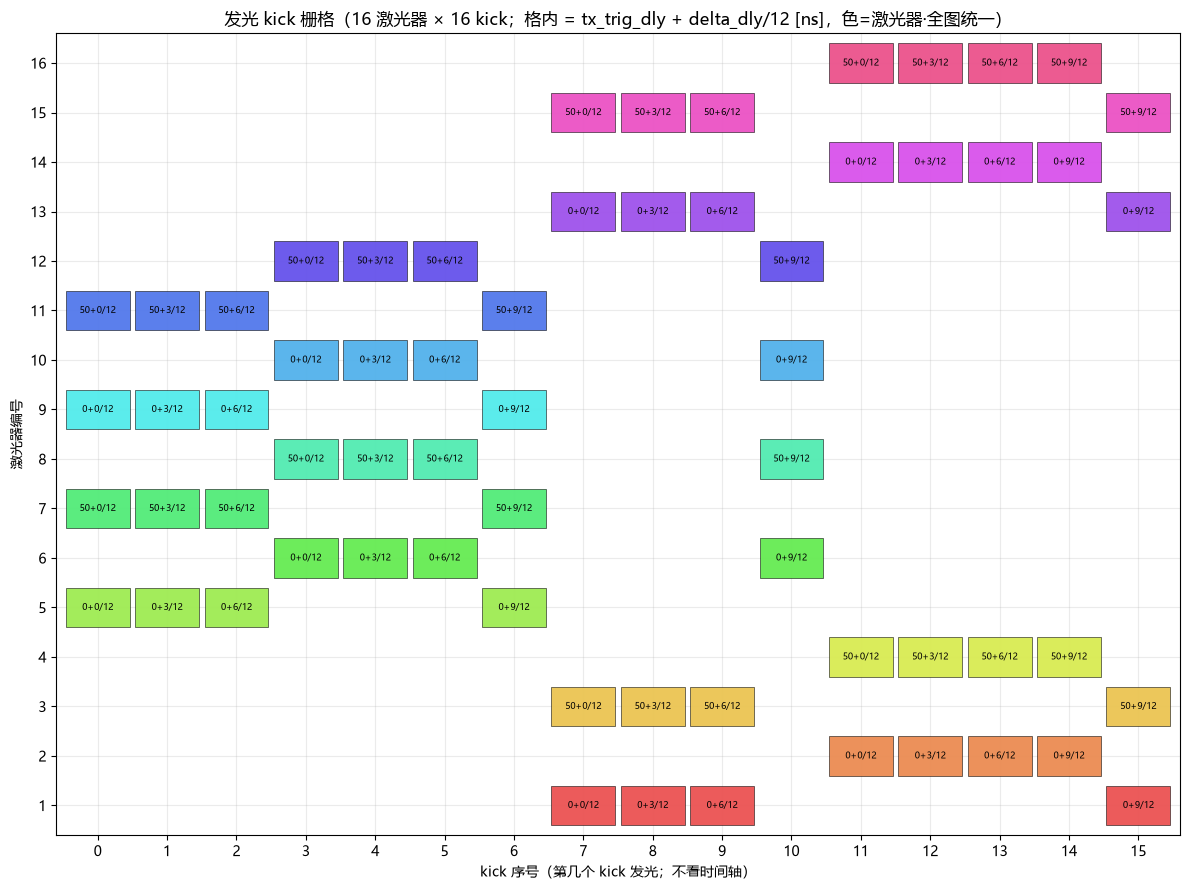

In [ ]:
# ============================================================================
# 绘图 1：激光发光 kick 栅格（v13：只留此图，删掉时间轴放大下图）
# ============================================================================
# 【kick 栅格】：x 轴 = kick 序号(0~15)，y 轴 = 激光器；只看"第几 kick 发光"，不看时间轴。
#   格内文字 = 该激光器在该 kick 的编码：tx_trig_dly + delta_dly·(1/12)  写作 "50+3/12"。
#   （delta_dly 取自 Excel 第4行 tdelay，本版计算时全 0；此处仅【展示】其原始编码值。）
# 比例约 4:3（横:纵），更紧凑。
fig, ax = plt.subplots(figsize=(12, 9))

# 每个激光器在每个 kick 是否发光：画方块 + 标编码。颜色用全局统一 laser_color()。
for e in firings:
    col = laser_color(e["laser"])
    ax.add_patch(plt.Rectangle((e["kick"] - 0.46, e["laser"] - 0.40), 0.92, 0.80,
                               facecolor=col, edgecolor="k", linewidth=0.4, alpha=0.95, zorder=2))
    # 编码标注：tx + delta/12（delta 取该 kick 的 Excel tdelay 原值，仅展示）
    _dd = tdelay_A.get(e["kick"], 0)
    ax.text(e["kick"], e["laser"], f"{e['tx']}+{_dd}/12", fontsize=6.5, ha="center", va="center",
            color="k", zorder=3)
# 栅格线
ax.set_xticks(range(16)); ax.set_yticks(laser_ids)
ax.set_xlim(-0.6, 15.6); ax.set_ylim(0.4, N_LASERS + 0.6)
ax.set_xlabel("kick 序号（第几个 kick 发光；不看时间轴）")
ax.set_ylabel("激光器编号")
ax.set_title(f"发光 kick 栅格（{N_LASERS} 激光器 × 16 kick；格内 = tx_trig_dly + delta_dly/12 [ns]，色=激光器·全图统一）")
ax.grid(alpha=0.25, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [5]:
# ============================================================================
# 核心检测：对给定物体距离 D，记录所有回波被各激光器接收的情况
# ============================================================================
def detect_echoes(D):
    """对距离 D 处的单个物体，返回所有"被记录的回波"列表。

    每条记录（dict）字段：
      emit_laser / emit_kick : 回波由哪个激光器、哪次 kick 发出
      recv_laser / recv_kick : 被哪个激光器、在它哪次 kick 的 TOF 窗里收到
      target_D               : 物体真实距离 [m]
      true_tof               : 真实飞行时间 2D/c [s]
      t_echo                 : 回波到达绝对时刻 [s]
      rec_tof                : 记录的飞行时间 = t_echo − t_ref_收 [s]
      rec_dist               : 记录的距离 = rec_tof·c/2 [m]（鬼影会 ≠ D）
      is_true                : 是否真回波（发==收 且 同一 kick）
      negligible             : 该串扰是否【空间可忽略】(编号间隔>CROSSTALK_MAX_GAP)；真回波恒 False
    """
    t_tof = 2.0 * D / C_LIGHT
    recs = []
    for e in firings:                       # 每个发射事件
        t_echo = e["t_fire"] + t_tof
        for w in firings:                   # 检查每个接收窗（含自己）
            if w["t_fire"] <= t_echo <= w["t_fire"] + TOF_WINDOW:
                rec_tof = t_echo - w["t_ref"]
                is_true = (e["laser"] == w["laser"] and e["kick"] == w["kick"])
                recs.append({
                    "emit_laser": e["laser"], "emit_kick": e["kick"],
                    "recv_laser": w["laser"], "recv_kick": w["kick"],
                    "target_D": D, "true_tof": t_tof, "t_echo": t_echo,
                    "rec_tof": rec_tof, "rec_dist": rec_tof * C_LIGHT / 2.0,
                    "is_true": is_true,
                    # 空间可忽略：非真回波 且 收发编号间隔 > 阈值。真回波恒 False。
                    "negligible": (not is_true) and crosstalk_negligible(e["laser"], w["laser"]),
                })
    return recs


# ---- 快速自检：一个近距离物体 ----
_D = 30.0
_r = detect_echoes(_D)
_nt = sum(1 for x in _r if x["is_true"])
_ng = sum(1 for x in _r if x["negligible"])
_gkeep = sum(1 for x in _r if (not x["is_true"]) and (not x["negligible"]))
print(f"自检 D={_D:.0f}m：共 {len(_r)} 条记录，其中真回波 {_nt} 条、鬼影 {len(_r)-_nt} 条")
print(f"  鬼影里：空间可忽略(编号间隔>{CROSSTALK_MAX_GAP}) {_ng} 条、不可忽略 {_gkeep} 条")
print(f"  真实 tof = {2*_D/C_LIGHT*1e9:.2f} ns（真实距离 {_D:.1f} m）")
if _r:
    _g = [x for x in _r if not x["is_true"]]
    _gd = sorted(set(round(x["rec_dist"], 2) for x in _g))
    print(f"  鬼影出现的记录距离（去重）：{_gd} m")


自检 D=30m：共 256 条记录，其中真回波 64 条、鬼影 192 条
  鬼影里：空间可忽略(编号间隔>2) 112 条、不可忽略 80 条
  真实 tof = 200.14 ns（真实距离 30.0 m）
  鬼影出现的记录距离（去重）：[22.51, 30.0, 37.49] m


In [6]:
# ============================================================================
# 验证：几个特定距离的鬼影分布（仿真 vs 解析预测）
# ============================================================================
# 选点用意：
#   D=30m  (2D/c=200ns)  —— 远小于窗，只有同 kick 串扰；tx=0/50ns → 预期 ±7.5m 鬼影
#   D=150m (2D/c=1000ns) —— 窗内正常测距；同 kick 串扰
#   D=330m (2D/c=2200ns) —— 恰好 = 1 个 KICK_SPACING！真回波超窗丢失，混叠进下一 kick
#   D=480m (2D/c=3202ns) —— 超窗，混叠进下一 kick 窗；预期伪装成 ~150m
D_TEST = [30.0, 150.0, 330.0, 480.0]

def dist_offset_from_tx(dtx_ns):
    """tx 差 dtx(ns) 对应的鬼影距离偏移 [m]。"""
    return dtx_ns * NS * C_LIGHT / 2.0

print("=" * 84)
print("特定距离验证（KICK_SPACING={:.1f}μs, TOF_WINDOW={:.0f}ns, D_UNAMBIG={:.0f}m）".format(
    KICK_SPACING*1e6, TOF_WINDOW*1e9, D_UNAMBIG))
print("=" * 84)

verify_cache = {}
for D in D_TEST:
    recs = detect_echoes(D)
    verify_cache[D] = recs
    n_true = sum(1 for x in recs if x["is_true"])
    n_ghost = len(recs) - n_true
    tof_ns = 2*D/C_LIGHT*1e9

    # 记录距离直方（按 0.1m 归并去重，看鬼影落在哪些"假距离"）
    from collections import Counter
    dist_cnt = Counter(round(x["rec_dist"], 1) for x in recs)
    ghost_cnt = Counter(round(x["rec_dist"], 1) for x in recs if not x["is_true"])

    print(f"\n【D = {D:.0f} m】 真实 tof = {tof_ns:.1f} ns  (2D/c)")
    print(f"  记录总数 {len(recs)}：真回波 {n_true}，鬼影 {n_ghost}")
    if 2*D/C_LIGHT > TOF_WINDOW:
        print(f"  ⚠ 2D/c={tof_ns:.0f}ns > 窗{TOF_WINDOW*1e9:.0f}ns  → 真回波超窗，本距离【无法被正确测距】(n_true应=0)")
    print(f"  各记录距离(≥1条) : " +
          ", ".join(f"{d}m×{c}" for d, c in sorted(dist_cnt.items())))

    # ---- 解析预测 ----
    if D <= D_UNAMBIG:
        # 同 kick 串扰：发/收 tx 差 ∈ {-50,0,+50} → 距离偏移 {-7.5,0,+7.5} m
        preds = sorted(set(round(D + dist_offset_from_tx(dtx), 1) for dtx in (-50, 0, 50)))
        print(f"  解析预测(同kick, tx差±50ns→±7.5m)：鬼影/真值应落在 {preds} m")
    else:
        # 混叠：回波落入下一个 kick 窗，rec_tof = 2D/c − KICK_SPACING (+ tx差)
        base_alias_ns = (2*D/C_LIGHT - KICK_SPACING) * 1e9
        base_alias_m = base_alias_ns * NS * C_LIGHT / 2.0
        preds = sorted(set(round(base_alias_m + dist_offset_from_tx(dtx), 1) for dtx in (-50, 0, 50)))
        print(f"  解析预测(混叠到下一kick: 2D/c−KICK_SPACING={base_alias_ns:.0f}ns)：鬼影应落在 {preds} m")

    # ---- 比对 ----
    sim_ghost = sorted(ghost_cnt.keys())
    ok = set(sim_ghost).issubset(set(preds)) or set(preds).issubset(set(sim_ghost + ([round(D,1)] if D<=D_UNAMBIG else [])))
    print(f"  仿真鬼影距离 = {sim_ghost} m   →  与解析预测 {'✔ 一致' if set(sim_ghost)<=set(preds) else '⚠ 需检查'}")


特定距离验证（KICK_SPACING=2.2μs, TOF_WINDOW=2000ns, D_UNAMBIG=300m）

【D = 30 m】 真实 tof = 200.1 ns  (2D/c)
  记录总数 256：真回波 64，鬼影 192
  各记录距离(≥1条) : 22.5m×64, 30.0m×128, 37.5m×64
  解析预测(同kick, tx差±50ns→±7.5m)：鬼影/真值应落在 [22.5, 30.0, 37.5] m
  仿真鬼影距离 = [22.5, 30.0, 37.5] m   →  与解析预测 ✔ 一致

【D = 150 m】 真实 tof = 1000.7 ns  (2D/c)
  记录总数 256：真回波 64，鬼影 192
  各记录距离(≥1条) : 142.5m×64, 150.0m×128, 157.5m×64
  解析预测(同kick, tx差±50ns→±7.5m)：鬼影/真值应落在 [142.5, 150.0, 157.5] m
  仿真鬼影距离 = [142.5, 150.0, 157.5] m   →  与解析预测 ✔ 一致

【D = 330 m】 真实 tof = 2201.5 ns  (2D/c)
  记录总数 180：真回波 0，鬼影 180
  ⚠ 2D/c=2202ns > 窗2000ns  → 真回波超窗，本距离【无法被正确测距】(n_true应=0)
  各记录距离(≥1条) : 0.2m×120, 7.7m×60
  解析预测(混叠到下一kick: 2D/c−KICK_SPACING=2ns)：鬼影应落在 [-7.3, 0.2, 7.7] m
  仿真鬼影距离 = [0.2, 7.7] m   →  与解析预测 ✔ 一致

【D = 480 m】 真实 tof = 3202.2 ns  (2D/c)
  记录总数 240：真回波 0，鬼影 240
  ⚠ 2D/c=3202ns > 窗2000ns  → 真回波超窗，本距离【无法被正确测距】(n_true应=0)
  各记录距离(≥1条) : 142.7m×60, 150.2m×120, 157.7m×60
  解析预测(混叠到下一kick: 2D/c−KICK_SPACING=1002ns)：鬼影应落在 [142.7, 150.

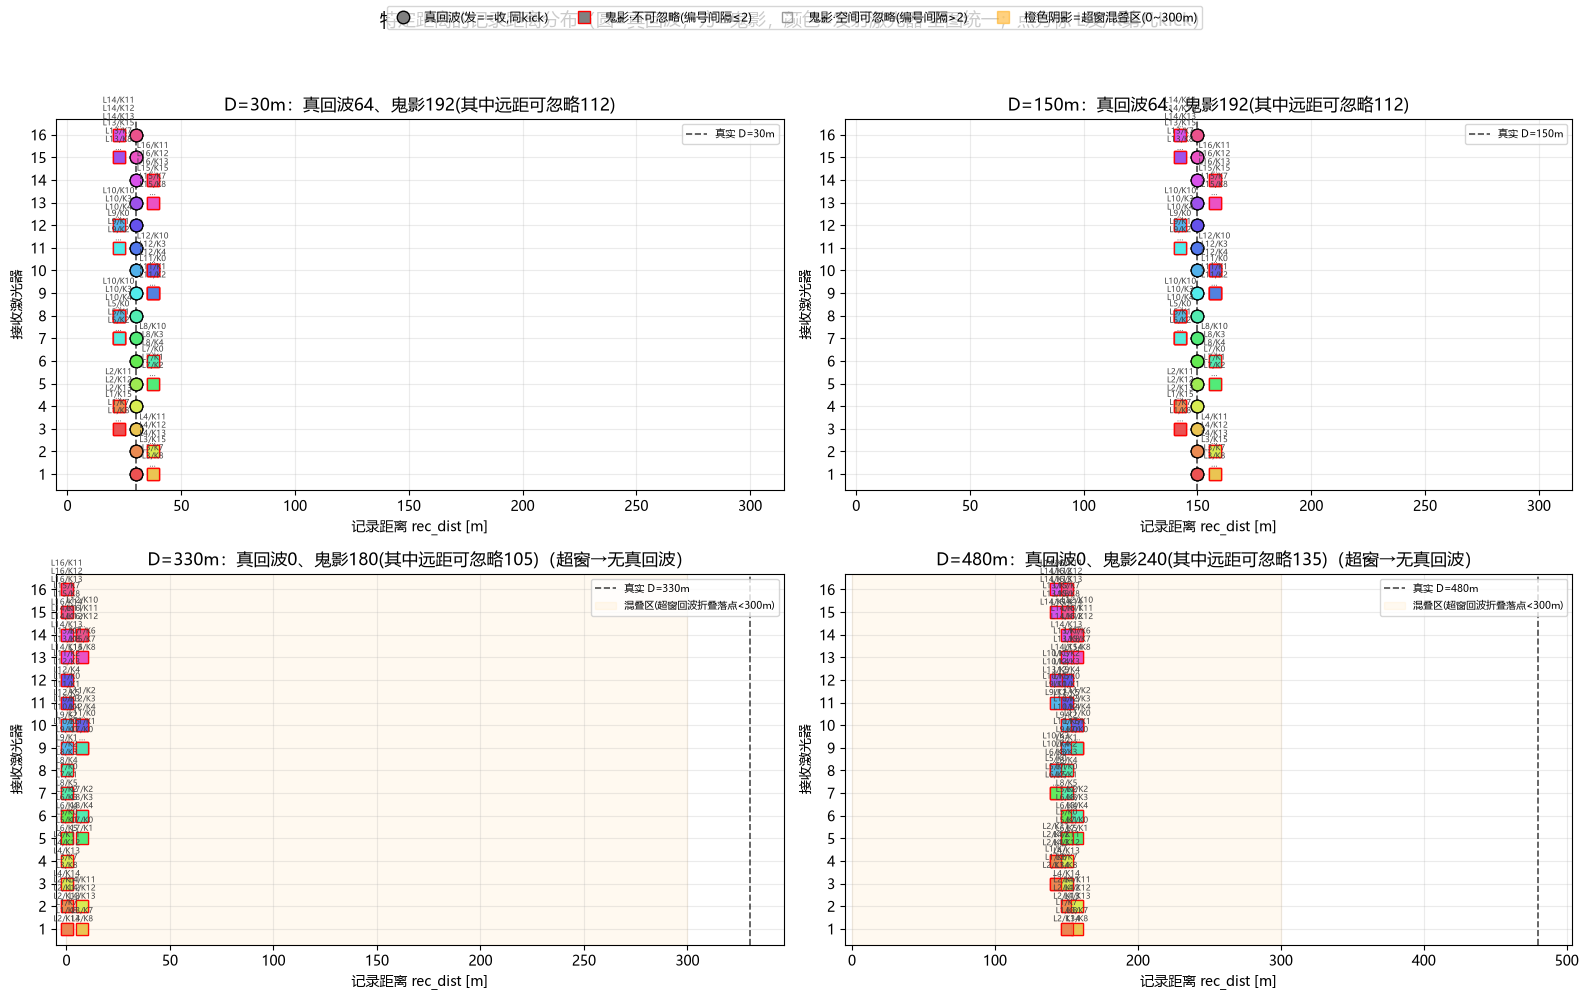


鬼影来源明细：每条鬼影 = 某激光器某 kick 发射的回波，被别的接收器记录成错误距离

【D=30m】 鬼影 192 条（按 记录距离→接收器 归并；显示 发射来源×次数）
      记录距离    接收器  发射来源(L发/K第几kick × 次数)
  -------- ------  --------------------------------------------------
     22.5m     L3  L1/K15, L1/K7, L1/K8, L1/K9, L13/K15, L13/K7, L13/K8, L13/K9
     22.5m     L4  L14/K11, L14/K12, L14/K13, L14/K14, L2/K11, L2/K12, L2/K13, L2/K14
     22.5m     L7  L5/K0, L5/K1, L5/K2, L5/K6, L9/K0, L9/K1, L9/K2, L9/K6
     22.5m     L8  L10/K10, L10/K3, L10/K4, L10/K5, L6/K10, L6/K3, L6/K4, L6/K5
     22.5m    L11  L5/K0, L5/K1, L5/K2, L5/K6, L9/K0, L9/K1, L9/K2, L9/K6
     22.5m    L12  L10/K10, L10/K3, L10/K4, L10/K5, L6/K10, L6/K3, L6/K4, L6/K5
     22.5m    L15  L1/K15, L1/K7, L1/K8, L1/K9, L13/K15, L13/K7, L13/K8, L13/K9
     22.5m    L16  L14/K11, L14/K12, L14/K13, L14/K14, L2/K11, L2/K12, L2/K13, L2/K14
     30.0m     L1  L13/K15, L13/K7, L13/K8, L13/K9
     30.0m     L2  L14/K11, L14/K12, L14/K13, L14/K14
     30.0m     L3  L15/K15, L15/K7, L15/K8, L15/K9
   

In [7]:
# ============================================================================
# 绘图 2：特定距离的"记录距离"分布图（横轴=算出的距离，纵轴=接收激光器）
# ============================================================================
# 圆=真回波（发==收，同kick），方=鬼影；颜色=发射激光器。
# 竖虚线=物体真实距离 D。橙色阴影=混叠区(超窗后回波折叠回来的位置)。
# v11：① 每条鬼影在点旁标注来源"L发/K第几kick"；② 底部打印每条鬼影的完整来源明细表；
#      ③ shaded 超窗混叠区加图例文字说明。
from collections import defaultdict

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, D in zip(axes.ravel(), D_TEST):
    recs = verify_cache[D]
    # 按 (接收器, 记录距离四舍五入) 聚合，便于把同簇来源标在一起，避免文字互相压盖
    cluster = defaultdict(list)     # {(recv_laser, round(rec_dist,1)): [记录,...]}
    for x in recs:
        cluster[(x["recv_laser"], round(x["rec_dist"], 1))].append(x)

    for x in recs:
        col = laser_color(x["emit_laser"])          # v12 统一配色（同一激光器恒定同色）
        if x["is_true"]:
            ax.plot(x["rec_dist"], x["recv_laser"], "o", color=col, ms=9,
                    mec="k", mew=0.8, zorder=6)
        elif x["negligible"]:
            # 空间可忽略鬼影：空心灰点、半透明（视觉弱化）
            ax.plot(x["rec_dist"], x["recv_laser"], "s", mfc="none", mec="0.6",
                    mew=0.9, ms=7, zorder=4, alpha=0.6)
        else:
            ax.plot(x["rec_dist"], x["recv_laser"], "s", color=col, ms=8,
                    mec="red", mew=0.9, zorder=5, alpha=0.9)

    # 每个"鬼影簇"标注来源（L发/K第几kick）；簇内多来源用换行列出。只标"不可忽略"的来源。
    for (rlid, rd), xs in cluster.items():
        ghosts = [g for g in xs if (not g["is_true"]) and (not g["negligible"])]
        if not ghosts:
            continue
        srcs = sorted(set(f"L{g['emit_laser']}/K{g['emit_kick']}" for g in ghosts))
        # 太多来源只标前 3 个 + 省略号，完整清单见下方打印
        txt = "\n".join(srcs[:3]) + ("\n…" if len(srcs) > 3 else "")
        ax.annotate(txt, (rd, rlid), fontsize=5.5, ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points", color="0.25", zorder=7)

    ax.axvline(D, color="k", ls="--", lw=1.2, alpha=0.7, label=f"真实 D={D:.0f}m")
    if D > D_UNAMBIG:
        ax.axvspan(0, D_UNAMBIG, color="orange", alpha=0.06,
                   label=f"混叠区(超窗回波折叠落点<300m)")
    n_true = sum(1 for x in recs if x["is_true"])
    n_negl = sum(1 for x in recs if x["negligible"])
    ax.set_xlabel("记录距离 rec_dist [m]"); ax.set_ylabel("接收激光器")
    ax.set_yticks(laser_ids); ax.set_ylim(0.3, N_LASERS + 0.7)
    ax.set_xlim(-5, max(D_UNAMBIG, D) * 1.05)
    ax.set_title(f"D={D:.0f}m：真回波{n_true}、鬼影{len(recs)-n_true}(其中远距可忽略{n_negl})"
                 + ("（超窗→无真回波）" if D > D_UNAMBIG else ""))
    ax.legend(fontsize=7.5, loc="upper right"); ax.grid(alpha=0.25)

# 图例说明
from matplotlib.lines import Line2D
legend_el = [
    Line2D([0], [0], marker="o", color="w", mfc="gray", mec="k", ms=9, label="真回波(发==收,同kick)"),
    Line2D([0], [0], marker="s", color="w", mfc="gray", mec="red", ms=8, label="鬼影·不可忽略(编号间隔≤%d)" % CROSSTALK_MAX_GAP),
    Line2D([0], [0], marker="s", color="w", mfc="none", mec="0.6", ms=7, label="鬼影·空间可忽略(编号间隔>%d)" % CROSSTALK_MAX_GAP),
    Line2D([0], [0], marker="s", color="w", mfc="orange", mec="orange", ms=9, alpha=0.5,
           label="橙色阴影=超窗混叠区(0~300m)"),
]
fig.legend(handles=legend_el, loc="upper center", ncol=4, fontsize=8.5)
plt.suptitle("特定距离的记录距离分布（圆=真回波，方=鬼影，颜色=发射激光器·全图统一；点旁标 L发/K第几kick）",
             y=0.995, fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ---- 鬼影来源完整明细打印（图上标不下的在这里逐条列出）----
print("\n" + "=" * 88)
print("鬼影来源明细：每条鬼影 = 某激光器某 kick 发射的回波，被别的接收器记录成错误距离")
print("=" * 88)
for D in D_TEST:
    recs = verify_cache[D]
    ghosts = [x for x in recs if not x["is_true"]]
    print(f"\n【D={D:.0f}m】 鬼影 {len(ghosts)} 条（按 记录距离→接收器 归并；显示 发射来源×次数）")
    # 按 (记录距离, 接收器) 归并，列出发射来源
    agg = defaultdict(lambda: defaultdict(int))   # {(rec_dist, recv): {发射源: 次数}}
    for g in ghosts:
        agg[(round(g["rec_dist"],1), g["recv_laser"])][f"L{g['emit_laser']}/K{g['emit_kick']}"] += 1
    print(f"  {'记录距离':>8} {'接收器':>6}  发射来源(L发/K第几kick × 次数)")
    print(f"  {'-'*8} {'-'*6}  {'-'*50}")
    for (rd, rlid) in sorted(agg.keys()):
        srcs = agg[(rd, rlid)]
        src_str = ", ".join(f"{s}×{n}" if n > 1 else s for s, n in sorted(srcs.items()))
        print(f"  {rd:>7.1f}m {('L'+str(rlid)):>6}  {src_str}")


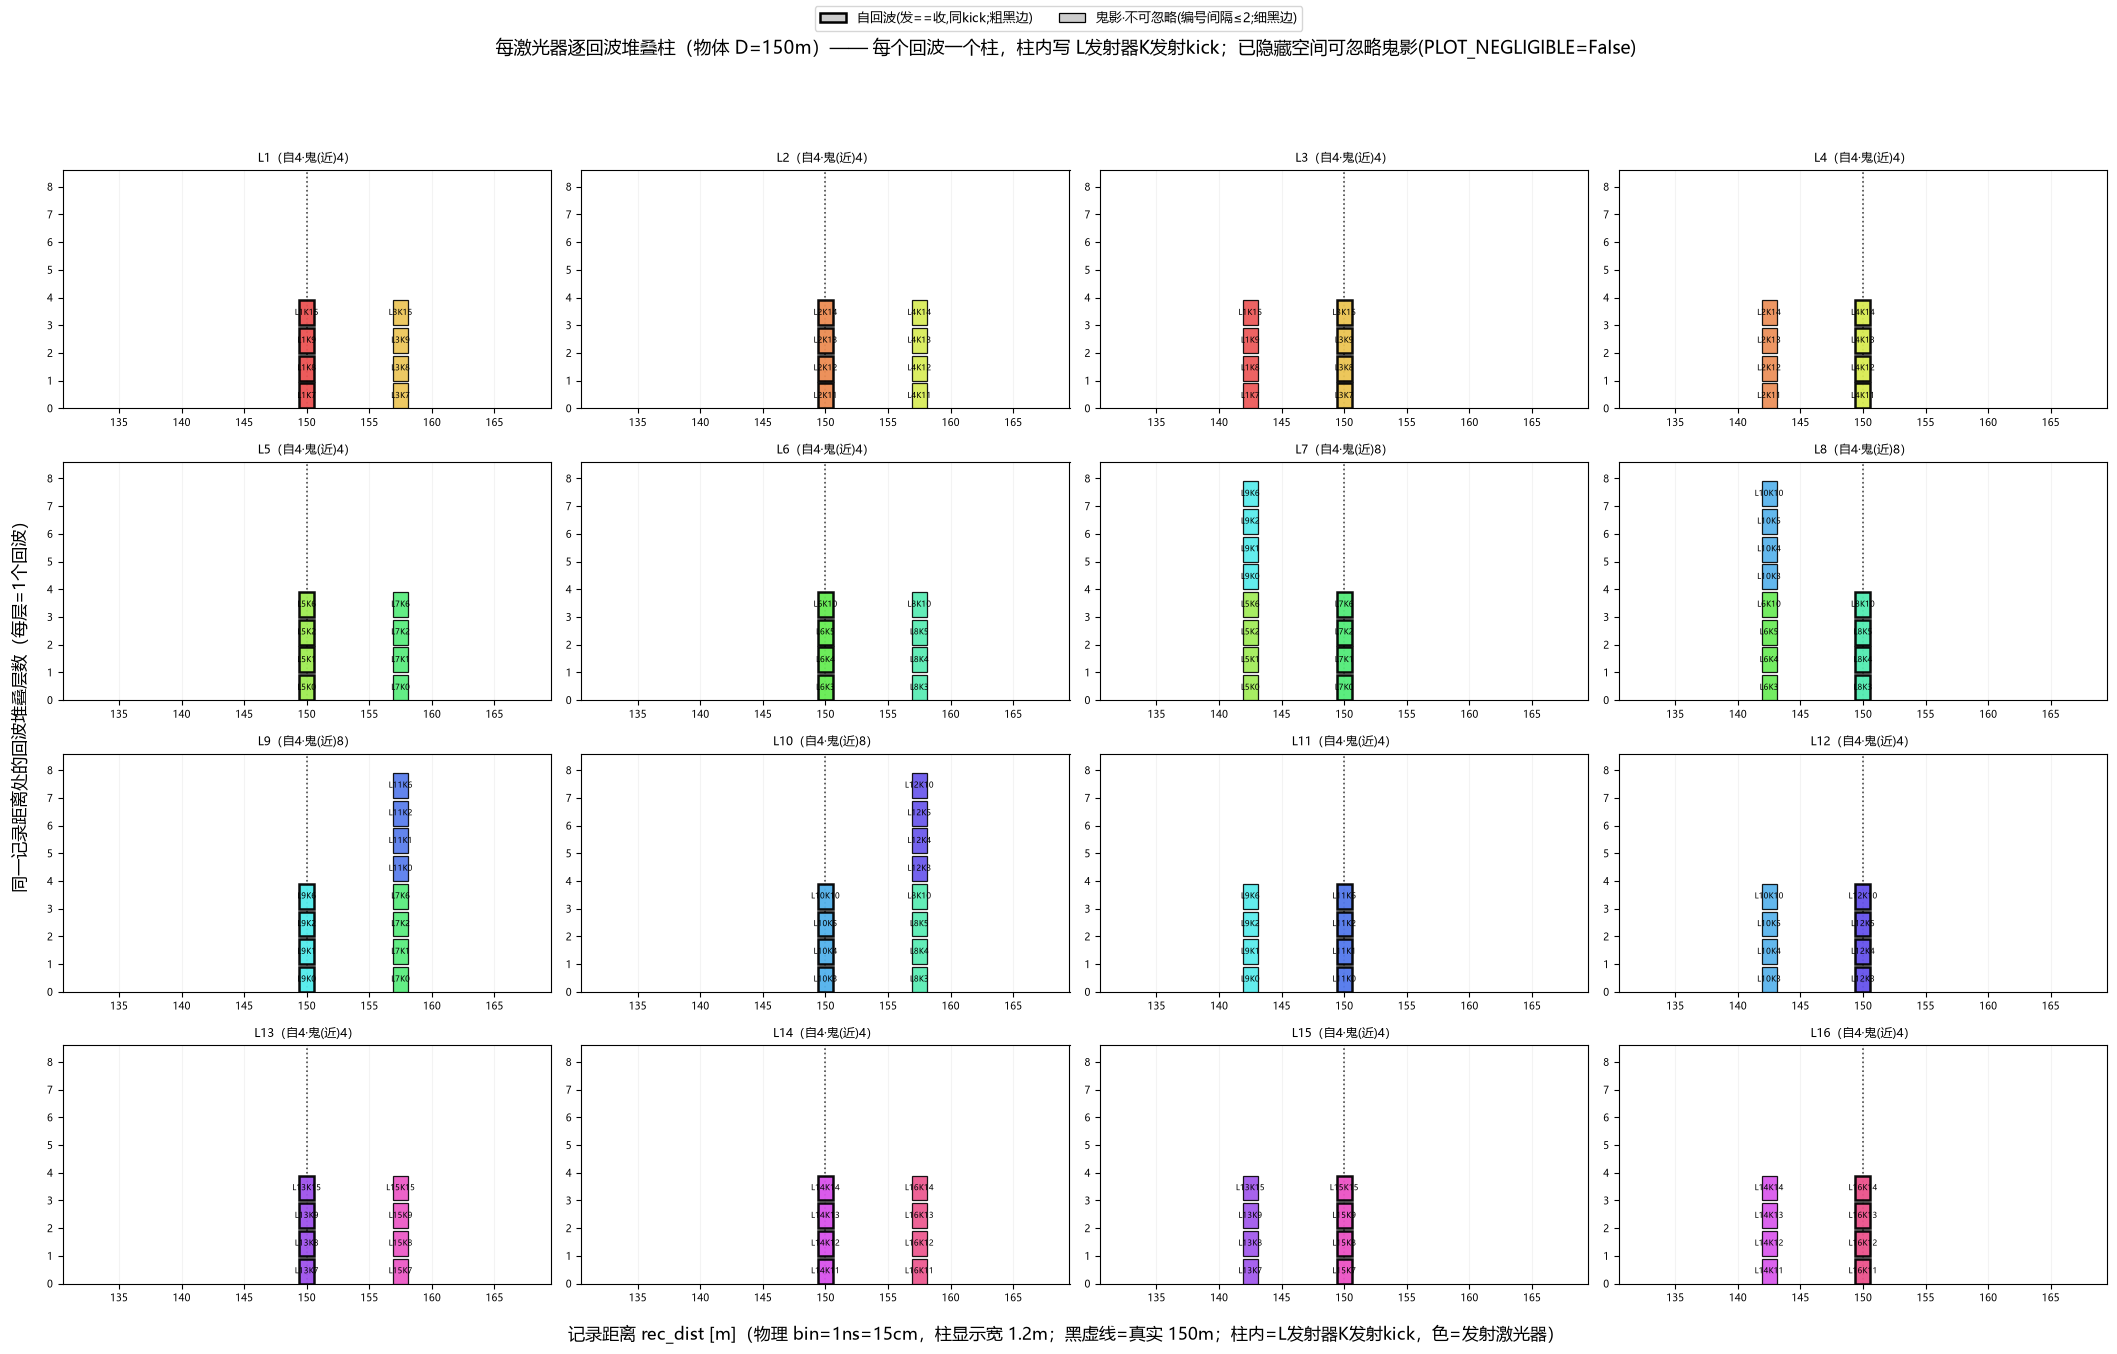

每激光器累加 TOF（D=150m）汇总：
  Laser   收到   自回波   鬼影       自回波距离[m] 鬼影距离[m]
  L   1   16     4   12        [150.0] [150.0, 157.5]
  L   2   16     4   12        [150.0] [150.0, 157.5]
  L   3   16     4   12        [150.0] [142.5, 150.0]
  L   4   16     4   12        [150.0] [142.5, 150.0]
  L   5   16     4   12        [150.0] [150.0, 157.5]
  L   6   16     4   12        [150.0] [150.0, 157.5]
  L   7   16     4   12        [150.0] [142.5, 150.0]
  L   8   16     4   12        [150.0] [142.5, 150.0]
  L   9   16     4   12        [150.0] [150.0, 157.5]
  L  10   16     4   12        [150.0] [150.0, 157.5]
  L  11   16     4   12        [150.0] [142.5, 150.0]
  L  12   16     4   12        [150.0] [142.5, 150.0]
  L  13   16     4   12        [150.0] [150.0, 157.5]
  L  14   16     4   12        [150.0] [150.0, 157.5]
  L  15   16     4   12        [150.0] [142.5, 150.0]
  L  16   16     4   12        [150.0] [142.5, 150.0]

每条回波完整溯源（物体真实 D=150m；类型：自=自回波/鬼=串扰鬼影；可忽略=空间上编号间隔>2）
    接收器   类型  

In [8]:
# ============================================================================
# 绘图 3：每个激光器的【4 次发光累加 TOF 波形】—— 逐回波堆叠柱
# ============================================================================
# 每一个回波（不同 kick 要区分开）都画成一个【带边框的柱】，同一记录距离处上下叠加；
#   柱内写"LxKx"（发射激光器 + 发射 kick），颜色=发射激光器。
#   自回波=粗黑边；鬼影(不可忽略)=细黑边；鬼影(空间可忽略, 编号间隔>阈值)=灰虚线边+半透明。
# v13：可忽略鬼影(编号间隔 > CROSSTALK_MAX_GAP)是否画出来，由 PLOT_NEGLIGIBLE 开关控制（默认不画）。
PLOT_NEGLIGIBLE = False        # True: 画出空间可忽略鬼影；False(默认): 不画（图更干净）

D_CUMUL = 150.0
recs_c = detect_echoes(D_CUMUL)

BIN_M = 0.15                                   # 物理 bin 宽 [m]（=1ns 往返）
CELL_W = 1.2                                   # 每个回波柱的显示宽度 [m]（仅显示，不改物理分辨率）

# 按开关决定要画哪些回波（可忽略的默认剔除）
recs_plot = [x for x in recs_c if PLOT_NEGLIGIBLE or not x["negligible"]]

# 回波落点范围 -> 统一 x 轴聚焦区间（用实际要画的点）
_all_d = np.array([x["rec_dist"] for x in recs_plot])
if _all_d.size:
    _xlo = max(0.0, _all_d.min() - 12); _xhi = min(D_UNAMBIG, _all_d.max() + 12)
else:
    _xlo, _xhi = 0.0, D_UNAMBIG


def _stack_key(rec_dist):
    """把记录距离量化到 0.15m 物理 bin，用作"同一距离"的堆叠键（同 bin 的回波上下叠）。"""
    return round(rec_dist / BIN_M)


fig, axes = plt.subplots(4, 4, figsize=(22, 14))
_ymax_all = 1
for idx, lid in enumerate(laser_ids):
    ax = axes[idx // 4][idx % 4]
    mine = [x for x in recs_plot if x["recv_laser"] == lid]
    # 同一记录距离 bin 内，按 (类型, 发射器, kick) 排个稳定序，再从下往上堆叠
    from collections import defaultdict as _dd
    stacks = _dd(list)
    for x in sorted(mine, key=lambda x: (not x["is_true"], x["emit_laser"], x["emit_kick"])):
        stacks[_stack_key(x["rec_dist"])].append(x)

    for kbin, items in stacks.items():
        xc = kbin * BIN_M
        for level, x in enumerate(items):
            col = laser_color(x["emit_laser"])
            if x["is_true"]:
                ec, lw, ls, al = "k", 1.8, "solid", 0.95           # 自回波：粗黑边
            elif x["negligible"]:
                ec, lw, ls, al = "0.5", 0.8, (0,(2,1)), 0.45       # 可忽略鬼影：灰虚线+半透明
            else:
                ec, lw, ls, al = "k", 0.9, "solid", 0.9            # 不可忽略鬼影：细黑边
            ax.add_patch(plt.Rectangle((xc - CELL_W/2, level), CELL_W, 0.9,
                                       facecolor=col, edgecolor=ec, linewidth=lw,
                                       linestyle=ls, alpha=al, zorder=3))
            # 柱内写 "LxKx"（发射激光器 + 发射 kick）
            ax.text(xc, level + 0.45, f"L{x['emit_laser']}K{x['emit_kick']}", fontsize=5.5,
                    ha="center", va="center", color="k", zorder=4)
        _ymax_all = max(_ymax_all, len(items))

    ax.axvline(D_CUMUL, color="k", ls=":", lw=1.2, alpha=0.7)
    n_self = sum(1 for x in mine if x["is_true"])
    n_negl = sum(1 for x in mine if x["negligible"])
    n_keep = len(mine) - n_self - n_negl
    ax.set_title(f"L{lid}（自{n_self}·鬼(近){n_keep}" + (f"·鬼(远,可忽略){n_negl}" if PLOT_NEGLIGIBLE else "") + "）", fontsize=8.5)
    ax.set_xlim(_xlo, _xhi)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.15, axis="x")

# 统一 y 轴上限（堆叠层数）
for idx in range(len(laser_ids)):
    axes[idx // 4][idx % 4].set_ylim(0, _ymax_all + 0.6)

fig.text(0.5, 0.045, f"记录距离 rec_dist [m]（物理 bin=1ns=15cm，柱显示宽 {CELL_W}m；黑虚线=真实 {D_CUMUL:.0f}m；柱内=L发射器K发射kick，色=发射激光器）",
         ha="center", fontsize=12)
fig.text(0.02, 0.5, "同一记录距离处的回波堆叠层数（每层=1个回波）", va="center", rotation="vertical", fontsize=12)
# 图例：类别边框说明（可忽略项仅在开启绘制时列出）
from matplotlib.patches import Patch
leg = [
    Patch(facecolor="0.8", edgecolor="k", linewidth=1.8, label="自回波(发==收,同kick;粗黑边)"),
    Patch(facecolor="0.8", edgecolor="k", linewidth=0.9, label="鬼影·不可忽略(编号间隔≤%d;细黑边)" % CROSSTALK_MAX_GAP),
]
if PLOT_NEGLIGIBLE:
    leg.append(Patch(facecolor="0.8", edgecolor="0.5", linewidth=0.8, linestyle="--",
                     label="鬼影·空间可忽略(编号间隔>%d;灰虚线半透明)" % CROSSTALK_MAX_GAP))
fig.legend(handles=leg, loc="upper center", ncol=3, fontsize=9.5)
plt.suptitle(f"每激光器逐回波堆叠柱（物体 D={D_CUMUL:.0f}m）—— 每个回波一个柱，柱内写 L发射器K发射kick"
             + ("" if PLOT_NEGLIGIBLE else "；已隐藏空间可忽略鬼影(PLOT_NEGLIGIBLE=False)"),
             fontsize=13, y=0.975)
plt.tight_layout(rect=[0.03, 0.06, 0.98, 0.93])
plt.show()

print("=" * 76)
print(f"每激光器累加 TOF（D={D_CUMUL:.0f}m）汇总：")
print(f"  {'Laser':>5} {'收到':>4} {'自回波':>5} {'鬼影':>4} {'自回波距离[m]':>14} {'鬼影距离[m]'}")
for lid in laser_ids:
    mine = [x for x in recs_c if x["recv_laser"] == lid]
    d_self = sorted(set(round(x["rec_dist"],1) for x in mine if x["is_true"]))
    d_ghost = sorted(set(round(x["rec_dist"],1) for x in mine if not x["is_true"]))
    print(f"  L{lid:>4d} {len(mine):>4d} "
          f"{sum(1 for x in mine if x['is_true']):>5d} "
          f"{sum(1 for x in mine if not x['is_true']):>4d} "
          f"{str(d_self):>14s} {d_ghost}")

# ---- v12：每条回波的完整溯源明细（含"空间可忽略"标记）----
#   每条回波都回答：来自哪个激光器、它第几 kick 发射、在多少米处反射、被本激光器记录成多少米，
#   以及该串扰是否【空间可忽略】(编号间隔>CROSSTALK_MAX_GAP)。
print("\n" + "=" * 100)
print(f"每条回波完整溯源（物体真实 D={D_CUMUL:.0f}m；类型：自=自回波/鬼=串扰鬼影；可忽略=空间上编号间隔>{CROSSTALK_MAX_GAP}）")
print("=" * 100)
print(f"  {'接收器':>5} {'类型':>4} {'可忽略':>5} | {'发射激光器':>8} {'发射kick':>7} {'反射距离[m]':>11} {'记录距离[m]':>11} {'误差[m]':>8}")
print(f"  {'-'*5} {'-'*4} {'-'*5} | {'-'*8} {'-'*7} {'-'*11} {'-'*11} {'-'*8}")
for lid in laser_ids:
    # 排序：自回波在前；鬼影中不可忽略在前、可忽略在后；再按记录距离
    mine = sorted([x for x in recs_c if x["recv_laser"] == lid],
                  key=lambda x: (not x["is_true"], x["negligible"], x["rec_dist"]))
    for x in mine:
        typ = "自" if x["is_true"] else "鬼"
        negl = "—" if x["is_true"] else ("忽略" if x["negligible"] else "保留")
        err = x["rec_dist"] - x["target_D"]
        print(f"  L{lid:>4d} {typ:>4} {negl:>5} | L{x['emit_laser']:>7d} K{x['emit_kick']:>6d} "
              f"{x['target_D']:>11.1f} {x['rec_dist']:>11.2f} {err:>+8.2f}")


In [9]:
# ============================================================================
# 总结
# ============================================================================
print("=" * 76)
print("crosstalk_sim_v13 总结")
print("=" * 76)
print(f"""
1. 数据源与配置
   - 时序：{EXCEL_FILE} [长焦 / A组]，{N_LASERS} 激光器 × 每个 4 次发光 = {N_FIRE} 发光事件
   - KICK_SPACING = {KICK_SPACING*1e6:.1f} μs，TOF_WINDOW = {TOF_WINDOW*1e9:.0f} ns
   - 最大无模糊距离 D_UNAMBIG = {D_UNAMBIG:.0f} m（超此距离真回波超窗 → 距离混叠鬼影）

2. 编码开关（本版）
   - tx_trig_dly : {'启用(Excel 0/50ns)' if ENC['use_tx_trig_dly'] else '关(全0)'}
   - delta_dly   : {'启用' if ENC['use_delta_dly'] else '关(全0，接口保留)'}
   - fpga_jitter : {'启用' if ENC['use_fpga_jitter'] else '关(全0，接口保留)'}

3. 核心模型
   - 每次发光 = 一次发射 + 一个 {TOF_WINDOW*1e9:.0f}ns 接收窗
   - 回波被每个激光器接收；落窗即记录 rec_tof = t_echo − t_ref_收
   - is_true = (发==收 且 同一 kick)；其余为鬼影

4. 验证结论（见上）
   - D≤300m：同 kick 串扰，tx=0/50ns 造成 ±7.5m 编码残差鬼影
   - D>300m：真回波超窗丢失，回波混叠进下一 kick 窗 → 伪装成近距离鬼影

5. 输出（v13 起不落地 PNG，仅在 notebook 内展示三张图）
   - 图1 发光 kick 栅格（格内 tx+delta/12，色=激光器）
   - 图2 4 个测试距离的记录距离分布（鬼影来源标注 + 可忽略串扰弱化）
   - 图3 每激光器逐回波堆叠柱（柱内写 LxKx，PLOT_NEGLIGIBLE 控制是否画可忽略鬼影）

6. 下一步（未做）
   - 打开 fpga_jitter（8ns 随机）看鬼影是否被打散
   - 全距离扫描 + 消鬼影算法（目标噪点率 10ppm）
   - 加入第二个模组 / 雷达对射
""")


crosstalk_sim_v13 总结

1. 数据源与配置
   - 时序：Elephant 时序表.xlsx [长焦 / A组]，16 激光器 × 每个 4 次发光 = 64 发光事件
   - KICK_SPACING = 2.2 μs，TOF_WINDOW = 2000 ns
   - 最大无模糊距离 D_UNAMBIG = 300 m（超此距离真回波超窗 → 距离混叠鬼影）

2. 编码开关（本版）
   - tx_trig_dly : 启用(Excel 0/50ns)
   - delta_dly   : 关(全0，接口保留)
   - fpga_jitter : 关(全0，接口保留)

3. 核心模型
   - 每次发光 = 一次发射 + 一个 2000ns 接收窗
   - 回波被每个激光器接收；落窗即记录 rec_tof = t_echo − t_ref_收
   - is_true = (发==收 且 同一 kick)；其余为鬼影

4. 验证结论（见上）
   - D≤300m：同 kick 串扰，tx=0/50ns 造成 ±7.5m 编码残差鬼影
   - D>300m：真回波超窗丢失，回波混叠进下一 kick 窗 → 伪装成近距离鬼影

5. 输出（v13 起不落地 PNG，仅在 notebook 内展示三张图）
   - 图1 发光 kick 栅格（格内 tx+delta/12，色=激光器）
   - 图2 4 个测试距离的记录距离分布（鬼影来源标注 + 可忽略串扰弱化）
   - 图3 每激光器逐回波堆叠柱（柱内写 LxKx，PLOT_NEGLIGIBLE 控制是否画可忽略鬼影）

6. 下一步（未做）
   - 打开 fpga_jitter（8ns 随机）看鬼影是否被打散
   - 全距离扫描 + 消鬼影算法（目标噪点率 10ppm）
   - 加入第二个模组 / 雷达对射

